In [1]:
import tensorflow as tf
import tensorflow_hub as hub
# import tensorflow_addons as tfa
import os
import cv2
import numpy as np
from tensorflow.keras import layers, models

# Dataset path
DATASET_PATH = "multi_class__short_ds_resized_128"
IMG_SIZE = (224, 224)  # I3D expects 224x224 input
SEQUENCE_LENGTH = 10
BATCH_SIZE = 6
EPOCHS = 20
NUM_CLASSES = 4  # accident, fighting, fire, normal_resized

# Data augmentation
train_augmentation = tf.keras.Sequential([
    layers.TimeDistributed(layers.RandomFlip("horizontal")),
    layers.TimeDistributed(layers.RandomRotation(0.1)),
    layers.TimeDistributed(layers.RandomZoom(0.1)),
])

# Load video dataset (each class in its own folder, each video as .mp4, .avi, etc.)
def load_video_paths_and_labels(dataset_path):
    class_names = sorted(os.listdir(dataset_path))
    video_paths, labels = [], []
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)
        for video_file in os.listdir(class_dir):
            if video_file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
                video_path = os.path.join(class_dir, video_file)
                video_paths.append(video_path)
                labels.append(label)
    return video_paths, labels, class_names

def extract_frames_from_video(video_path, img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_idxs = np.linspace(0, max(0, total_frames-1), seq_len, dtype=int)
    frames = []
    for idx in frame_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, img_size)
            frame = frame.astype(np.float32) / 255.0
        frames.append(frame)
    cap.release()
    return np.stack(frames)

def video_generator(video_paths, labels, batch_size=BATCH_SIZE, augment=False):
    idx = 0
    while True:
        batch_videos, batch_labels = [], []
        for _ in range(batch_size):
            if idx >= len(video_paths):
                idx = 0
            video = extract_frames_from_video(video_paths[idx])
            if augment:
                video = train_augmentation(tf.expand_dims(video, 0))[0].numpy()
            batch_videos.append(video)
            batch_labels.append(labels[idx])
            idx += 1
        yield np.stack(batch_videos), tf.one_hot(batch_labels, NUM_CLASSES)

# Load data
video_paths, labels, class_names = load_video_paths_and_labels(DATASET_PATH)
num_samples = len(video_paths)
train_size = int(0.8 * num_samples)
train_videos, train_labels = video_paths[:train_size], labels[:train_size]
val_videos, val_labels = video_paths[train_size:], labels[train_size:]

train_gen = video_generator(train_videos, train_labels, augment=True)
val_gen = video_generator(val_videos, val_labels, augment=False)
steps_per_epoch = len(train_videos) // BATCH_SIZE
validation_steps = len(val_videos) // BATCH_SIZE

# Custom model subclass to use I3D KerasLayer correctly
class I3DClassifier(tf.keras.Model):
    def __init__(self, num_classes):
        super().__init__()
        self.base_model = hub.KerasLayer("https://tfhub.dev/deepmind/i3d-kinetics-400/1", trainable=False)
        self.dense1 = layers.Dense(256, activation='relu')
        self.dropout = layers.Dropout(0.5)
        self.out = layers.Dense(num_classes, activation='softmax')
    def call(self, inputs):
        x = self.base_model(inputs)
        x = self.dense1(x)
        x = self.dropout(x)
        return self.out(x)

model = I3DClassifier(NUM_CLASSES)

# Compile and train as before
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.CategoricalAccuracy()]
 )

model.summary()

# Train
model.fit(
    train_gen,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps
)

# Optionally unfreeze more layers and fine-tune
# for layer in model.layers:
#     layer.trainable = True
# model.compile(...)
# model.fit(...)

model.save('finetuned_i3d_model.keras')
print('Training complete. Model saved as finetuned_i3d_model.keras')

2025-09-08 14:17:03.799325: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1757319450.894162   21946 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:10:00.0, compute capability: 7.5


Model: "i3d_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 5/25 ━━━━━━━━━━━━━━━━━━━━ 28:56 87s/step - accuracy: 0.0000e+00 - categorical_accuracy: 0.0000e+00 - loss: 4.4986

2025-09-08 14:25:27.779717: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 32s:

  %convolution.412 = f32[6,5,112,112,64]{4,3,2,1,0} convolution(%constant.411, %constant.410), window={size=7x7x7 stride=2x2x2 pad=2_3x2_3x2_3}, dim_labels=b012f_012io->b012f, metadata={op_type="Conv3D" op_name="i3d_classifier_1/keras_layer/StatefulPartitionedCall/RGB/inception_i3d/Conv3d_1a_7x7/conv_3d/convolution" source_file="/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1221}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and

 6/25 ━━━━━━━━━━━━━━━━━━━━ 27:26 87s/step - accuracy: 0.0000e+00 - categorical_accuracy: 0.0000e+00 - loss: 4.4145

2025-09-08 14:27:25.855499: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1m4s:

  %convolution.412 = f32[6,5,112,112,64]{4,3,2,1,0} convolution(%constant.411, %constant.410), window={size=7x7x7 stride=2x2x2 pad=2_3x2_3x2_3}, dim_labels=b012f_012io->b012f, metadata={op_type="Conv3D" op_name="i3d_classifier_1/keras_layer/StatefulPartitionedCall/RGB/inception_i3d/Conv3d_1a_7x7/conv_3d/convolution" source_file="/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1221}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo an

25/25 ━━━━━━━━━━━━━━━━━━━━ 2184s 87s/step - accuracy: 0.1533 - categorical_accuracy: 0.1533 - loss: 2.8211 - val_accuracy: 0.3056 - val_categorical_accuracy: 0.3056 - val_loss: 2.0877
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2161s 86s/step - accuracy: 0.4200 - categorical_accuracy: 0.4200 - loss: 1.5367 - val_accuracy: 0.5278 - val_categorical_accuracy: 0.5278 - val_loss: 1.2437
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 557ms/step - accuracy: 0.5000 - categorical_accuracy: 0.5000 - loss: 1.2945 - val_accuracy: 0.4722 - val_categorical_accuracy: 0.4722 - val_loss: 1.2011
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step - accuracy: 0.6067 - categorical_accuracy: 0.6067 - loss: 0.9814 - val_accuracy: 0.6667 - val_categorical_accuracy: 0.6667 - val_loss: 0.9448
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 463ms/step - accuracy: 0.6600 - categorical_accuracy: 0.6600 - loss: 0.8065 - val_accuracy: 0.6389 - val_categorical_accuracy: 0.6389 - val_loss: 1.0517
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━

In [ ]:
# Check if TensorFlow is using the GPU
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('Num GPUs Available:', len(gpus))
if gpus:
    print('GPU(s) detected:')
    for gpu in gpus:
        print('  -', gpu)
    print('Is built with CUDA:', tf.test.is_built_with_cuda())
else:
    print('No GPU detected. Training will run on CPU.')

In [1]:
# Check TensorFlow GPU and CUDA availability
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('Num GPUs Available:', len(tf.config.list_physical_devices('GPU')))
print('Built with CUDA:', tf.test.is_built_with_cuda())
print('CUDA version:', tf.sysconfig.get_build_info().get('cuda_version', 'N/A'))
print('CUDNN version:', tf.sysconfig.get_build_info().get('cudnn_version', 'N/A'))

2025-09-08 01:21:04.921313: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
Num GPUs Available: 1
Built with CUDA: True
CUDA version: 12.5.1
CUDNN version: 9


📊 Dataset split:
Train+Validation samples: 144 (will be used for 3-fold CV)
Test samples: 48 (held out for final evaluation)
Class names: ['accident', 'fighting', 'fire', 'normal_resized']
🔄 Starting 3-fold Cross Validation...
Total samples for CV: 144

==================== FOLD 1/3 ====================
Fold 1 - Train: 96, Val: 48
Training fold 1...
Evaluating fold 1...
✅ Fold 1 Accuracy: 0.7708

==================== FOLD 2/3 ====================
Fold 2 - Train: 96, Val: 48
Training fold 2...
Evaluating fold 2...
✅ Fold 2 Accuracy: 0.6875

==================== FOLD 3/3 ====================
Fold 3 - Train: 96, Val: 48
Training fold 3...
Evaluating fold 3...
✅ Fold 3 Accuracy: 0.6875

CROSS-VALIDATION RESULTS
Individual fold scores: ['0.7708', '0.6875', '0.6875']
Mean CV Accuracy: 0.7153 ± 0.0393
Best fold accuracy: 0.7708
Worst fold accuracy: 0.6875

TRAINING FINAL MODEL ON ALL TRAIN+VAL DATA
Final training steps per epoch: 24


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       688,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,947,140 (11.24 MB)

 Trainable params: 689,156 (2.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

🚀 Training final model...
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 36s 529ms/step - accuracy: 0.4861 - loss: 2.1242 - learning_rate: 1.0000e-04
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 575ms/step - accuracy: 0.6597 - loss: 1.8028 - learning_rate: 1.0000e-04
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 602ms/step - accuracy: 0.7014 - loss: 1.6864 - learning_rate: 1.0000e-04
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 614ms/step - accuracy: 0.7986 - loss: 1.5594 - learning_rate: 1.0000e-04
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 597ms/step - accuracy: 0.8264 - loss: 1.4929 - learning_rate: 1.0000e-04
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 550ms/step - accuracy: 0.8333 - loss: 1.4124 - learning_rate: 1.0000e-04
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 526ms/step - accuracy: 0.8889 - loss: 1.3309 - learning_rate: 1.0000e-04
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 537ms/step - accuracy: 0.9097 - loss: 1.2624 - learning_rate: 1.0000e-04
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step -

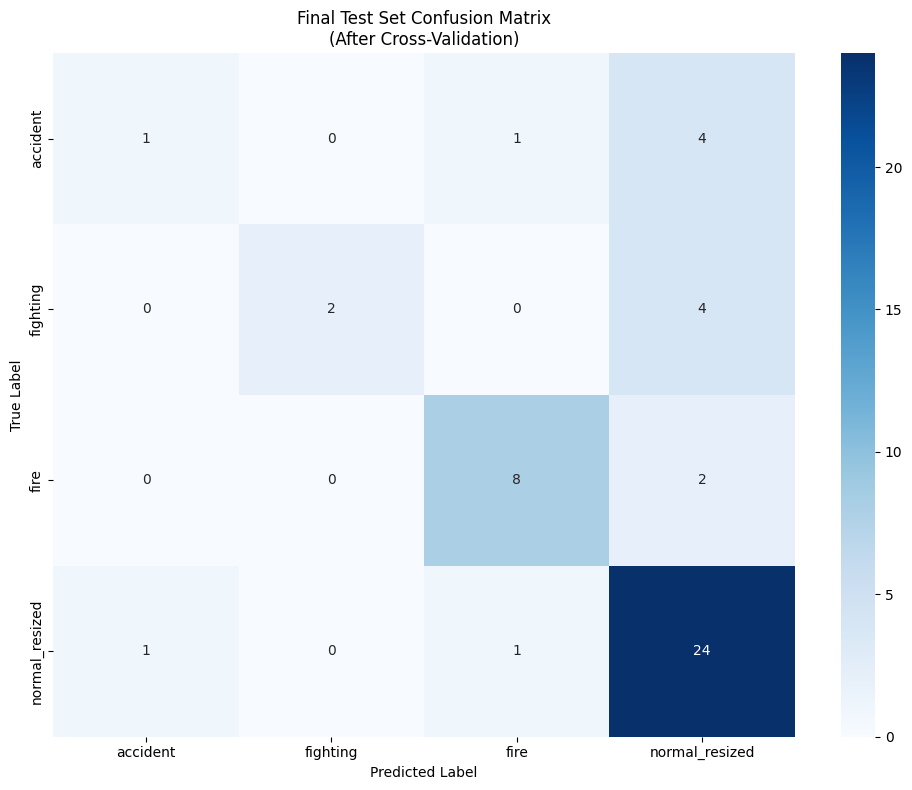


Final Classification Report:
                precision    recall  f1-score   support

      accident     0.5000    0.1667    0.2500         6
      fighting     1.0000    0.3333    0.5000         6
          fire     0.8000    0.8000    0.8000        10
normal_resized     0.7059    0.9231    0.8000        26

      accuracy                         0.7292        48
     macro avg     0.7515    0.5558    0.5875        48
  weighted avg     0.7365    0.7292    0.6937        48


DETAILED METRICS

Class: accident
Precision: 0.5000
Recall (True Positive Rate): 0.1667
F1-Score: 0.2500
Support: 6

Class: fighting
Precision: 1.0000
Recall (True Positive Rate): 0.3333
F1-Score: 0.5000
Support: 6

Class: fire
Precision: 0.8000
Recall (True Positive Rate): 0.8000
F1-Score: 0.8000
Support: 10

Class: normal_resized
Precision: 0.7059
Recall (True Positive Rate): 0.9231
F1-Score: 0.8000
Support: 26

Overall Metrics:
Macro Average Precision: 0.7515
Macro Average Recall: 0.5558
Macro Average F1-Score

In [11]:
import tensorflow as tf
import os
import cv2
import numpy as np
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold

# ----------------------------
# Configuration
# ----------------------------
DATASET_PATH = "multi_class__short_ds_resized_128"
IMG_SIZE = (224, 224)
SEQUENCE_LENGTH = 10
BATCH_SIZE = 6
EPOCHS = 30
NUM_CLASSES = 4  # accident, fighting, fire, normal_resized

# ----------------------------
# Enhanced Data augmentation (More diverse)
# ----------------------------
train_augmentation = tf.keras.Sequential([
    layers.TimeDistributed(layers.RandomFlip("horizontal")),
    layers.TimeDistributed(layers.RandomRotation(0.15)),  # Increased
    layers.TimeDistributed(layers.RandomZoom(0.15)),      # Increased
    layers.TimeDistributed(layers.RandomBrightness(0.1)), # New
    layers.TimeDistributed(layers.RandomContrast(0.1)),   # New
])

# ----------------------------
# Load dataset (video -> label)
# ----------------------------
def load_video_paths_and_labels(dataset_path):
    class_names = sorted(os.listdir(dataset_path))
    video_paths, labels = [], []
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)
        for video_file in os.listdir(class_dir):
            if video_file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
                video_paths.append(os.path.join(class_dir, video_file))
                labels.append(label)
    return video_paths, labels, class_names

# ----------------------------
# Extract frames from video
# ----------------------------
def extract_frames_from_video(video_path, img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_idxs = np.linspace(0, max(0, total_frames-1), seq_len, dtype=int)
    frames = []

    for idx in frame_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, img_size)
            frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    return np.stack(frames)

# ----------------------------
# Video generator
# ----------------------------
def video_generator(video_paths, labels, batch_size=BATCH_SIZE, augment=False):
    idx = 0
    while True:
        batch_videos, batch_labels = [], []
        for _ in range(batch_size):
            if idx >= len(video_paths):
                idx = 0
            video = extract_frames_from_video(video_paths[idx])
            if augment:
                video = train_augmentation(tf.expand_dims(video, 0))[0].numpy()
            batch_videos.append(video)
            batch_labels.append(labels[idx])
            idx += 1
        yield np.stack(batch_videos), tf.one_hot(batch_labels, NUM_CLASSES)

# ----------------------------
# Build heavily regularized model (Anti-overfitting)
# ----------------------------
def build_regularized_mobilenet_lstm(num_classes, sequence_length=SEQUENCE_LENGTH, img_size=IMG_SIZE):
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size[0], img_size[1], 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(sequence_length, img_size[0], img_size[1], 3), dtype=tf.float32)

    # Apply MobileNetV2 on each frame
    x = layers.TimeDistributed(base_model)(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # Heavily regularized LSTM (reduced complexity and regularization)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False,
                                        kernel_regularizer=regularizers.l2(0.001),  # Reduced
                                        recurrent_regularizer=regularizers.l2(0.001)))(x)
    x = layers.Dropout(0.4)(x)  # Moderate dropout

    # Output layer with minimal regularization
    outputs = layers.Dense(num_classes, activation="softmax",
                          kernel_regularizer=regularizers.l2(0.001))(x)
    
    return models.Model(inputs, outputs)

# ----------------------------
# Cross-validation function (Train+Val only)
# ----------------------------
def cross_validate_model(video_paths, labels, class_names, n_folds=3):
    """
    Perform cross-validation on training+validation data (NOT test set)
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_scores = []
    fold_histories = []
    
    print(f"🔄 Starting {n_folds}-fold Cross Validation...")
    print(f"Total samples for CV: {len(video_paths)}")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(video_paths, labels)):
        print(f"\n{'='*20} FOLD {fold+1}/{n_folds} {'='*20}")
        
        # Split data for this fold
        fold_train_videos = [video_paths[i] for i in train_idx]
        fold_val_videos = [video_paths[i] for i in val_idx]
        fold_train_labels = [labels[i] for i in train_idx]
        fold_val_labels = [labels[i] for i in val_idx]
        
        print(f"Fold {fold+1} - Train: {len(fold_train_videos)}, Val: {len(fold_val_videos)}")
        
        # Create generators
        fold_train_gen = video_generator(fold_train_videos, fold_train_labels, augment=True)
        fold_val_gen = video_generator(fold_val_videos, fold_val_labels, augment=False)
        
        fold_steps_per_epoch = len(fold_train_videos) // BATCH_SIZE
        fold_validation_steps = len(fold_val_videos) // BATCH_SIZE
        
        # Skip fold if not enough data
        if fold_steps_per_epoch == 0 or fold_validation_steps == 0:
            print(f"⚠️  Skipping fold {fold+1} - insufficient data")
            continue
        
        # Create model
        model = build_regularized_mobilenet_lstm(NUM_CLASSES)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        # Callbacks
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=0
        )
        
        lr_scheduler = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=0
        )
        
        # Train
        print(f"Training fold {fold+1}...")
        history = model.fit(
            fold_train_gen,
            epochs=EPOCHS,
            steps_per_epoch=fold_steps_per_epoch,
            validation_data=fold_val_gen,
            validation_steps=fold_validation_steps,
            callbacks=[early_stopping, lr_scheduler],
            verbose=0
        )
        
        # Evaluate this fold
        val_predictions = []
        val_true_labels = []
        
        print(f"Evaluating fold {fold+1}...")
        for i in range(fold_validation_steps):
            batch_videos, batch_labels = next(fold_val_gen)
            predictions = model.predict(batch_videos, verbose=0)
            val_predictions.extend(np.argmax(predictions, axis=1))
            val_true_labels.extend(np.argmax(batch_labels, axis=1))
        
        fold_accuracy = (np.array(val_predictions) == np.array(val_true_labels)).mean()
        fold_scores.append(fold_accuracy)
        fold_histories.append(history)
        
        print(f"✅ Fold {fold+1} Accuracy: {fold_accuracy:.4f}")
        
        # Clean up memory
        del model
        tf.keras.backend.clear_session()
    
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    
    print(f"\n{'='*50}")
    print(f"CROSS-VALIDATION RESULTS")
    print(f"{'='*50}")
    print(f"Individual fold scores: {[f'{score:.4f}' for score in fold_scores]}")
    print(f"Mean CV Accuracy: {mean_score:.4f} ± {std_score:.4f}")
    print(f"Best fold accuracy: {max(fold_scores):.4f}")
    print(f"Worst fold accuracy: {min(fold_scores):.4f}")
    
    return mean_score, std_score, fold_scores, fold_histories

# ----------------------------
# Main execution
# ----------------------------
video_paths, labels, class_names = load_video_paths_and_labels(DATASET_PATH)

# Split: 75% train+val, 25% test (test set is NEVER used in CV)
train_val_videos, test_videos, train_val_labels, test_labels = train_test_split(
    video_paths, labels, test_size=0.25, random_state=42, stratify=labels
)

print(f"📊 Dataset split:")
print(f"Train+Validation samples: {len(train_val_videos)} (will be used for 3-fold CV)")
print(f"Test samples: {len(test_videos)} (held out for final evaluation)")
print(f"Class names: {class_names}")

# Perform 3-fold CV on train+validation data ONLY
cv_mean, cv_std, cv_scores, cv_histories = cross_validate_model(
    train_val_videos, train_val_labels, class_names, n_folds=3
)

# ----------------------------
# Train final model on all train+val data
# ----------------------------
print(f"\n{'='*50}")
print(f"TRAINING FINAL MODEL ON ALL TRAIN+VAL DATA")
print(f"{'='*50}")

# Use all train+val data for final model
final_train_gen = video_generator(train_val_videos, train_val_labels, augment=True)
final_steps_per_epoch = len(train_val_videos) // BATCH_SIZE

print(f"Final training steps per epoch: {final_steps_per_epoch}")

# Create final model
final_model = build_regularized_mobilenet_lstm(NUM_CLASSES)
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

# Callbacks for final training
early_stopping_final = EarlyStopping(
    monitor='loss',  # Monitor training loss since no validation split
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_final = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train final model
print("🚀 Training final model...")
final_history = final_model.fit(
    final_train_gen,
    epochs=EPOCHS,
    steps_per_epoch=final_steps_per_epoch,
    callbacks=[early_stopping_final, lr_scheduler_final]
)

# Save final model
final_model.save("final_cv_model_optimized.keras")
print("✅ Final model saved as final_cv_model_optimized.keras")

# ----------------------------
# Test on held-out test set
# ----------------------------
print(f"\n{'='*50}")
print(f"FINAL EVALUATION ON HELD-OUT TEST SET")
print(f"{'='*50}")

test_gen = video_generator(test_videos, test_labels, augment=False)
test_steps = len(test_videos) // BATCH_SIZE

test_predictions = []
test_true_labels = []

print("🔍 Generating predictions on held-out test set...")
for i in range(test_steps):
    batch_videos, batch_labels = next(test_gen)
    predictions = final_model.predict(batch_videos, verbose=0)
    
    test_predictions.extend(np.argmax(predictions, axis=1))
    test_true_labels.extend(np.argmax(batch_labels, axis=1))

test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)

print(f"Collected {len(test_predictions)} test predictions")

# Calculate final metrics
test_accuracy = (test_predictions == test_true_labels).mean()
test_error = 1.0 - test_accuracy

print(f"\n🎯 FINAL RESULTS:")
print(f"Cross-Validation Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Final Test Error: {test_error:.4f} ({test_error*100:.2f}%)")

# ----------------------------
# Detailed evaluation metrics
# ----------------------------
# Confusion Matrix
cm = confusion_matrix(test_true_labels, test_predictions)
print(f"\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names)
plt.title('Final Test Set Confusion Matrix\n(After Cross-Validation)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('final_confusion_matrix_cv.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print(f"\nFinal Classification Report:")
report = classification_report(test_true_labels, test_predictions, 
                             target_names=class_names, digits=4)
print(report)

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_true_labels, test_predictions, average=None
)

# Calculate overall metrics
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_true_labels, test_predictions, average='macro'
)

print("\n" + "="*50)
print("DETAILED METRICS")
print("="*50)

for i, class_name in enumerate(class_names):
    print(f"\nClass: {class_name}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall (True Positive Rate): {recall[i]:.4f}")
    print(f"F1-Score: {f1[i]:.4f}")
    print(f"Support: {support[i]}")

print(f"\nOverall Metrics:")
print(f"Macro Average Precision: {precision_macro:.4f}")
print(f"Macro Average Recall: {recall_macro:.4f}")
print(f"Macro Average F1-Score: {f1_macro:.4f}")

# Calculate True/False Positive/Negative rates per class
print("\n" + "="*50)
print("TRUE/FALSE POSITIVE/NEGATIVE RATES")
print("="*50)

for i, class_name in enumerate(class_names):
    # For multi-class, we calculate rates for each class vs all others
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate (Recall)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate (Specificity)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    print(f"\nClass: {class_name}")
    print(f"True Positive Rate (Sensitivity/Recall): {tpr:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")
    print(f"True Negative Rate (Specificity): {tnr:.4f}")
    print(f"False Negative Rate: {fnr:.4f}")
    print(f"True Positives: {tp}")
    print(f"False Positives: {fp}")
    print(f"True Negatives: {tn}")
    print(f"False Negatives: {fn}")

print(f"\n{'='*50}")
print(f"FINAL SUMMARY")
print(f"{'='*50}")
print(f"📊 Cross-Validation Results:")
print(f"   • Mean CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"   • Individual folds: {[f'{score:.4f}' for score in cv_scores]}")
print(f"   • CV shows {'good' if cv_std < 0.05 else 'moderate' if cv_std < 0.10 else 'high'} variance")

print(f"📊 Final Test Results:")
print(f"   • Test Accuracy: {test_accuracy:.4f}")
print(f"   • Test Error Rate: {test_error:.4f}")
print(f"   • Macro F1-Score: {f1_macro:.4f}")
print(f"   • Model saved as: final_cv_model_optimized.keras")

# Model performance assessment
if abs(cv_mean - test_accuracy) < 0.05:
    print(f"✅ Good generalization: CV and test scores are close")
elif test_accuracy < cv_mean - 0.1:
    print(f"⚠️  Possible overfitting: Test score significantly lower than CV")
else:
    print(f"🤔 Model performance within expected range")

print(f"\n🎯 Anti-overfitting techniques applied:")
print(f"   • Enhanced data augmentation (5 types)")
print(f"   • Reduced L2 regularization (0.001)")
print(f"   • Moderate dropout (0.4)")
print(f"   • Learning rate scheduling")
print(f"   • Early stopping")
print(f"   • 3-fold cross-validation")
print(f"   • Stratified data splitting")